In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [94]:
fund= pd.read_csv("../data/processed/01_fund_master_cleaned.csv", parse_dates=["launch_date"])

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv", parse_dates=["date"])

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv", parse_dates=["date"])

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv", parse_dates=["month"])

category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv", parse_dates=["month"])

folio_count = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv", parse_dates=["month"])

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv", parse_dates=["transaction_date"])

portfolio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv", parse_dates=["portfolio_date"])

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv", parse_dates=["date"])

In [95]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv", parse_dates=["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [96]:
nav = nav.sort_values(['amfi_code', 'date'])

In [97]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [98]:
results = []

for code, group in nav.groupby('amfi_code'):
    
    returns = group['daily_return'].dropna()
    
    if len(returns) == 0:
        continue
    
    var95 = np.percentile(returns, 5)
    
    cvar95 = returns[returns <= var95].mean()
    
    results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar = pd.DataFrame(results)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [99]:
var_cvar.to_csv("../data/processed/var_cvar_report.csv", index=False)

In [100]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav = nav.dropna(subset=["daily_return"])

In [101]:
funds = (
    nav["amfi_code"]
    .value_counts()
    .head(5)
    .index
)

In [102]:
import numpy as np
import pandas as pd

In [103]:
rolling_sharpe = {}

for fund in funds:
    
    temp = nav[nav["amfi_code"] == fund].copy()
    temp = temp.sort_values("date")

    # rolling metrics
    roll_mean = temp["daily_return"].rolling(90).mean()
    roll_std = temp["daily_return"].rolling(90).std()

    sharpe = (roll_mean / roll_std) * np.sqrt(252)

    rolling_sharpe[fund] = sharpe

In [104]:
rolling_df = pd.DataFrame(rolling_sharpe)
rolling_df.head()

,100016,100025,100033,101206,101207
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


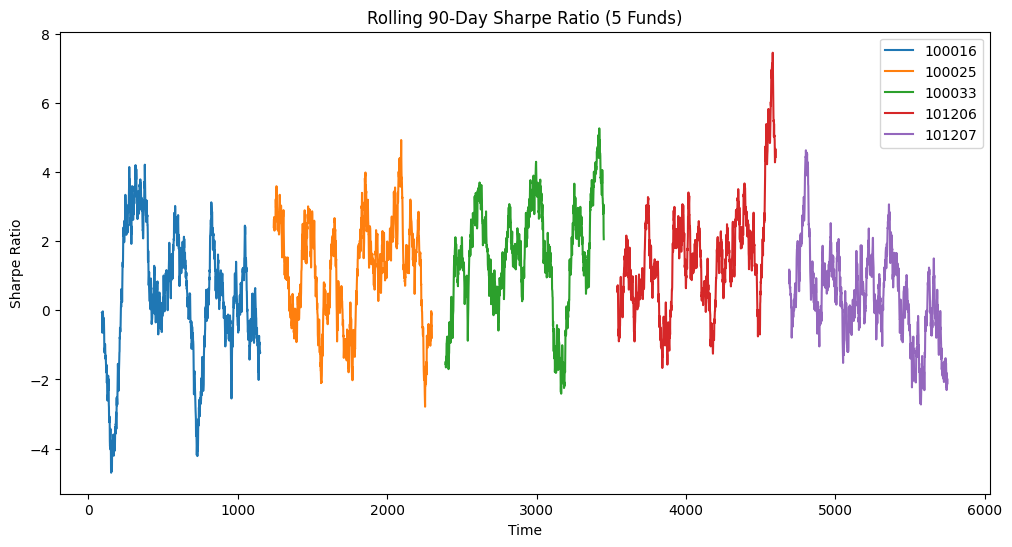

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for col in rolling_df.columns:
    plt.plot(rolling_df.index, rolling_df[col], label=str(col))

plt.title("Rolling 90-Day Sharpe Ratio (5 Funds)")
plt.xlabel("Time")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig("../data/processed/rolling_sharpe_chart.png", dpi=300, bbox_inches="tight")
plt.show()

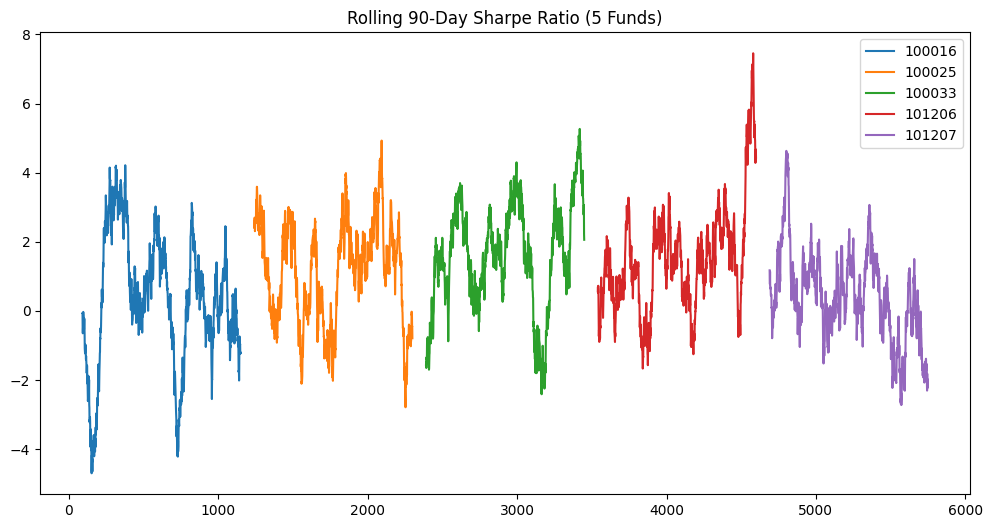

In [106]:
plt.figure(figsize=(12,6))

for col in rolling_df.columns:
    plt.plot(rolling_df.index, rolling_df[col], label=str(col))

plt.title("Rolling 90-Day Sharpe Ratio (5 Funds)")
plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [107]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [108]:
# Find the first transaction date of each investor
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
)

# Convert first transaction date into year
cohort_year = first_transaction.dt.year

# Map cohort year back to every transaction
transactions["cohort_year"] = transactions["investor_id"].map(cohort_year)

In [109]:
# Keep only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

# Calculate average SIP amount for each cohort
avg_sip = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="Average_SIP_Amount")
)

avg_sip

,cohort_year,Average_SIP_Amount
0,2024,10996.885825
1,2025,13505.209581


In [110]:
investment_transactions = transactions[
    transactions["transaction_type"].isin(["SIP", "Lumpsum"])
]

total_investment = (
    investment_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="Total_Investment")
)

total_investment

,cohort_year,Total_Investment
0,2024,2258062304
1,2025,18992635


In [111]:
top_fund = (
    investment_transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="Investment_Count")
)


top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "Investment_Count"],
        ascending=[True, False]
    )
    .drop_duplicates(subset="cohort_year")
)

top_fund = top_fund[["cohort_year", "amfi_code"]]

top_fund

,cohort_year,amfi_code
33,2024,125498
62,2025,119599


In [112]:
top_fund_check = (
    investment_transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="Investment_Count")
    .sort_values(
        ["cohort_year", "Investment_Count"],
        ascending=[True, False]
    )
)

top_fund_check.head()

,cohort_year,amfi_code,Investment_Count
33,2024,125498,752
35,2024,148568,737
4,2024,101207,733
17,2024,119095,733
24,2024,120504,733


In [113]:
top_fund_check[top_fund_check["cohort_year"] == 2024].head(5)

,cohort_year,amfi_code,Investment_Count
33,2024,125498,752
35,2024,148568,737
4,2024,101207,733
17,2024,119095,733
24,2024,120504,733


In [114]:
top_fund_check[top_fund_check["cohort_year"] == 2025].head(5)

,cohort_year,amfi_code,Investment_Count
62,2025,119599,11
67,2025,120507,9
71,2025,120844,9
43,2025,101206,8
44,2025,101207,8


In [116]:
fund = pd.read_csv(
    "../data/processed/01_fund_master_cleaned.csv",
    parse_dates=["launch_date"]
)

In [117]:
top_fund = top_fund.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund

,cohort_year,amfi_code,scheme_name
0,2024,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth
1,2025,119599,SBI Small Cap Fund - Direct Plan - Growth


In [118]:
cohort_analysis = (
    avg_sip
    .merge(total_investment, on="cohort_year")
    .merge(
        top_fund[["cohort_year", "scheme_name"]],
        on="cohort_year"
    )
)

cohort_analysis

,cohort_year,Average_SIP_Amount,Total_Investment,scheme_name
0,2024,10996.885825,2258062304,HDFC Mid-Cap Opportunities Fund - Direct - Growth
1,2025,13505.209581,18992635,SBI Small Cap Fund - Direct Plan - Growth


In [119]:
transactions.dtypes

investor_id                      str
transaction_date      datetime64[us]
amfi_code                      int64
transaction_type                 str
amount_inr                     int64
state                            str
city                             str
city_tier                        str
age_group                        str
gender                           str
annual_income_lakh           float64
payment_mode                     str
kyc_status                       str
cohort_year                    int32
dtype: object

In [120]:
# Keep only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [121]:
# Count SIP transactions for each investor
sip_count = (
    sip_transactions
    .groupby("investor_id")
    .size()
)

# Keep investors with 6 or more SIPs
eligible_investors = sip_count[sip_count >= 6].index

len(eligible_investors)

1362

In [122]:
print(len(eligible_investors))

1362


In [123]:
eligible_sips = sip_transactions[
    sip_transactions["investor_id"].isin(eligible_investors)
].copy()


eligible_sips = eligible_sips.sort_values(
    ["investor_id", "transaction_date"]
)


eligible_sips["gap_days"] = (
    eligible_sips
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

eligible_sips.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0
31897,INV000004,2025-05-17,119599,SIP,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,49.0
9329,INV000008,2024-05-27,101206,SIP,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,NaN
11113,INV000008,2024-06-23,102887,SIP,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified,2024,27.0
21549,INV000008,2024-12-05,100025,SIP,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified,2024,165.0
24389,INV000008,2025-01-18,119552,SIP,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,44.0


In [124]:
avg_gap = (
    eligible_sips
    .groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="Average_Gap_Days")
)

avg_gap.head()

,investor_id,Average_Gap_Days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [125]:
avg_gap["Status"] = np.where(
    avg_gap["Average_Gap_Days"] > 35,
    "At Risk",
    "Healthy"
)

avg_gap.head()

,investor_id,Average_Gap_Days,Status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [126]:
avg_gap["Status"].value_counts()

Status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [127]:
avg_gap["Average_Gap_Days"].describe()

count    1362.000000
mean       64.889132
std        15.593199
min        19.800000
25%        53.635417
50%        64.690476
75%        75.575000
max       102.600000
Name: Average_Gap_Days, dtype: float64

In [128]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [129]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [130]:
performance["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [ ]:
risk = input("Enter Risk Appetite (Low / Moderate / High): ")

In [135]:
risk = input("Enter Risk Appetite (Low / Moderate / High): ").strip().title()

filtered = performance[
    performance["risk_grade"] == risk
]

filtered.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low


In [138]:
print(risk)

Moderate


In [137]:
risk = input("Enter Risk Appetite (Low / Moderate / High): ").strip().title()

filtered = performance[
    performance["risk_grade"] == risk
]

filtered.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,0.96,0.82,1.12,14.0,-25.91,36022,1.42,4,Moderate


In [136]:
print(risk)

Low


In [139]:
risk = input("Enter Risk Appetite (Low / Moderate / High): ").strip().title()

filtered = performance[
    performance["risk_grade"] == risk
]

filtered.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High


In [140]:
print(risk)

High


In [141]:
portfolio_holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date',
       'portfolio_date0'],
      dtype='str')

In [142]:
portfolio_holdings["weight"] = (
    portfolio_holdings["weight_pct"] / 100
)


hhi = (
    portfolio_holdings
    .groupby("amfi_code")["weight"]
    .apply(lambda x: (x**2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [143]:
hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [144]:
fund["category"].value_counts().head(10)

category
Equity    34
Debt       6
Name: count, dtype: int64

In [145]:
# Get only Equity funds
equity_funds = fund[
    fund["category"] == "Equity"
][["amfi_code", "scheme_name"]]


equity_hhi = hhi.merge(
    equity_funds,
    on="amfi_code",
    how="inner"
)


equity_hhi = equity_hhi.sort_values(
    "HHI",
    ascending=False
)

equity_hhi.head(10)

,amfi_code,HHI,scheme_name
0,119092,0.206448,Axis Bluechip Fund - Regular - Growth
1,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
2,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
3,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
4,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
5,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
6,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
7,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
8,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
9,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [146]:
equity_hhi.head(5)

,amfi_code,HHI,scheme_name
0,119092,0.206448,Axis Bluechip Fund - Regular - Growth
1,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
2,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
3,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
4,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth


# Advanced Insights

### 1. Investor Cohort Behaviour

The investor cohort analysis shows that the **2025 cohort has a higher average SIP amount (₹13,505.21)** compared to the **2024 cohort (₹10,996.89)**. This suggests that newer investors in the dataset are contributing larger SIP investments on average.

### 2. SIP Continuity Analysis

Out of **1,362 investors** with at least six SIP transactions, **1,332 investors (approximately 97.8%)** were classified as **At Risk** because their average SIP interval exceeded 35 days, while only **30 investors** maintained regular investment intervals. This indicates significant irregularity in SIP contributions.

### 3. Portfolio Concentration Analysis

The HHI analysis identified **Axis Bluechip Fund - Regular - Growth** as the most concentrated equity fund in the dataset with an **HHI value of 0.206448**. Higher HHI values indicate greater concentration in fewer sectors and lower portfolio diversification.

### 4. Risk Analysis Using Historical VaR and CVaR

The Historical VaR and CVaR analysis provides an estimate of potential downside risk for each mutual fund scheme under adverse market conditions. Funds with larger negative VaR and CVaR values exhibit higher downside exposure and should be considered riskier from a loss perspective.

### 5. Risk-Adjusted Performance Analysis

The Rolling 90-Day Sharpe Ratio demonstrates that fund performance varies over time after adjusting for risk. Monitoring rolling Sharpe values can provide better investment insights than relying solely on long-term average returns, as market conditions continuously evolve.
